In [ ]:
# DataMining.ipynb

import os
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7,5)

# ---- Paths (đúng với CleanData output) ----
DATA_DIR = "."   # nếu bạn đang để file ngay root thì đổi thành "."
edges_path   = os.path.join("coauthor_edges.csv")
authors_path = os.path.join("authors.csv")

df_edges = pd.read_csv(edges_path)
df_authors = pd.read_csv(authors_path)

# ---- Schema checks ----
required_edges_cols = {"author1", "author2", "first_year", "weight"}
missing = required_edges_cols - set(df_edges.columns)
if missing:
    raise ValueError(f"coauthor_edges.csv thiếu cột: {missing}. "
                     "CleanData phải export đúng schema author1, author2, first_year, weight.")

print("Edges rows:", len(df_edges))
print("Year range:", int(df_edges["first_year"].min()), "-", int(df_edges["first_year"].max()))
print("Authors rows:", len(df_authors))
df_edges.head()


Edges rows: 23847
Year range: 1991 - 2003
Authors rows: 13003


,author1,author2,first_year,weight
0,A C Tort,F C Santos,2001,1
1,A Calogeracos,N Dombey,2000,1
2,A Calogeracos,P Kennedy,2000,1
3,A Dadda,M. Billo,1999,1
4,A Dadda,P. Provero,1999,1


In [ ]:
def build_full_graph(df_edges, df_authors=None):
    G = nx.Graph()

    # giữ cả isolated nodes (từ authors.csv)
    if df_authors is not None and not df_authors.empty and "author" in df_authors.columns:
        G.add_nodes_from(df_authors["author"].dropna().unique().tolist())

    # add edges (đúng schema CleanData)
    for a, b, first_year, weight in df_edges[["author1","author2","first_year","weight"]].itertuples(index=False, name=None):
        if pd.isna(a) or pd.isna(b) or a == b:
            continue
        G.add_edge(a, b, first_year=int(first_year), weight=int(weight))

    return G

G_full = build_full_graph(df_edges, df_authors)

print("Nodes:", G_full.number_of_nodes())
print("Edges:", G_full.number_of_edges())

Nodes: 13003
Edges: 23847


In [ ]:
def basic_stats(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    degs = [d for _, d in G.degree()]
    avg_deg = float(np.mean(degs)) if n > 0 else 0.0
    num_cc = nx.number_connected_components(G)
    clustering_global = nx.transitivity(G)  # global clustering coefficient

    print("===== BASIC NETWORK STATS =====")
    print("Nodes:", n)
    print("Edges:", m)
    print("Average degree:", avg_deg)
    print("Connected components:", num_cc)
    print("Global clustering coefficient:", clustering_global)

    return {
        "nodes": n,
        "edges": m,
        "avg_degree": avg_deg,
        "num_components": num_cc,
        "global_clustering": clustering_global
    }

stats = basic_stats(G_full)
stats

===== BASIC NETWORK STATS =====
Nodes: 13003
Edges: 23847
Average degree: 3.6679227870491427
Connected components: 2158
Global clustering coefficient: 0.2396160788529012


{'nodes': 13003,
 'edges': 23847,
 'avg_degree': 3.6679227870491427,
 'num_components': 2158,
 'global_clustering': 0.2396160788529012}

In [ ]:
components = sorted(nx.connected_components(G_full), key=len, reverse=True)
giant_nodes = components[0]
G_giant = G_full.subgraph(giant_nodes).copy()

print("===== GIANT COMPONENT =====")
print("Giant size:", G_giant.number_of_nodes(), f"({G_giant.number_of_nodes()/G_full.number_of_nodes()*100:.2f}%)")

# Các metric này có thể tốn thời gian nếu giant quá lớn; hep-th thường vẫn ổn
print("Average shortest path length (giant):", nx.average_shortest_path_length(G_giant))
print("Diameter (giant):", nx.diameter(G_giant))

===== GIANT COMPONENT =====
Giant size: 9079 (69.82%)
Average shortest path length (giant): 7.042399945779599
Diameter (giant): 22


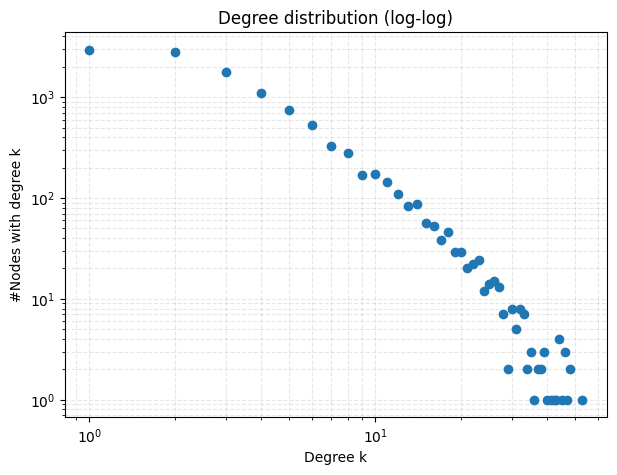

In [ ]:
degrees = np.array([d for _, d in G_full.degree()])
deg_counts = np.bincount(degrees)
k = np.arange(len(deg_counts))

plt.figure()
plt.loglog(k[1:], deg_counts[1:], marker="o", linestyle="none")
plt.xlabel("Degree k")
plt.ylabel("#Nodes with degree k")
plt.title("Degree distribution (log-log)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

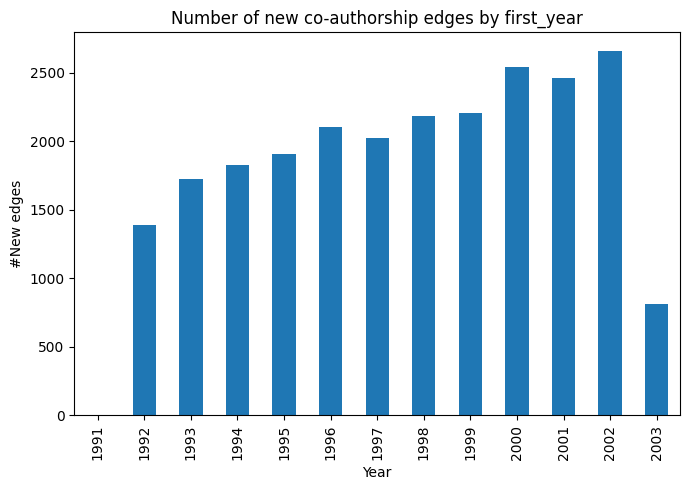

In [ ]:
edges_by_year = df_edges.groupby("first_year").size().sort_index()

plt.figure()
edges_by_year.plot(kind="bar")
plt.title("Number of new co-authorship edges by first_year")
plt.xlabel("Year")
plt.ylabel("#New edges")
plt.tight_layout()
plt.show()

In [ ]:
# Top by degree
deg_series = pd.Series(dict(G_full.degree())).sort_values(ascending=False)
top_deg = deg_series.head(10).reset_index()
top_deg.columns = ["author", "degree"]
top_deg

,author,degree
0,C. N. Pope,53
1,C. Vafa,48
2,M. Schweda,48
3,S. P. Sorella,47
4,H. Lu,46
5,Jr.,46
6,G. W. Gibbons,46
7,Andrew Strominger,45
8,Michael R. Douglas,44
9,P. K. Townsend,44
